# Exploring Vocabulary Dynamics in Reddit Diet Communities


Online communities on platforms like Reddit offer unique insights into group dynamics, shared interests, and evolving conversations. This notebook presents an in-depth linguistic analysis of various diet-related Reddit communities, examining how their vocabulary changes over time and reflects the distinctiveness of each group's identity. By leveraging advanced computational techniques, we aim to uncover patterns of linguistic behavior that characterize dynamic and stable communities alike.

Key objectives of this analysis include:
- Measuring **specificity**: How unique or generic is the vocabulary within a community during a given period?
- Evaluating **volatility**: How consistent or variable is the usage of specific terms across time?
- Assessing **distinctiveness**: How strongly does a community's language define its identity?
- Analyzing **user retention**: How effectively do communities retain active participants between periods?

To achieve these goals, the notebook integrates data cleaning, preprocessing, and advanced linguistic metrics with visualization techniques to generate meaningful insights. The corpus used for this analysis consists of top-level comments and Original Content (OC) posts from diet-focused Reddit communities over a defined timeline, including subreddits such as `keto`, `vegan`, `whole30`, and others.

By applying methods such as word frequency analysis, specificity-volatility plots, and community metrics, this research sheds light on the linguistic patterns that differentiate dynamic communities from stable ones.

---
### Loading the Dataset
This step involves loading a dataset that encompasses all comments and Original Content (OC) from the collected Reddit diet communities.

In [ ]:
from comid import Comid

cm = Comid()
files = ['../data/diets_submissions_2023_2024.json','../data/diets_comments_2023_2024.json']
cm.load_json_files(files=files)

Loading...:  50%|█████     | 1/2 [00:02<00:02,  2.03s/it]

### Filtering Relevant Data
To reduce noise in the dataset, conversation IDs are collected after removing OCs without authors or content. This ensures the data consists only of meaningful utterances.

Additionally, posts lacking authors or content are excluded, as the analysis computes vocabulary changes per author. Comments unrelated to the selected conversation IDs are filtered out.

In [2]:

from comid import Comid
cm = Comid()
files = ['full_diets_submissions_2023_2024.json','.full_diets_comments_2023_2024.json']
cm.load_json_files(files=files)

cm.clean_data(remove_no_author=True,remove_no_content=True)

Filtering posts: 100%|██████████| 2770373/2770373 [00:01<00:00, 2491753.49it/s]


Number of removed posts: 1379249


An overview of the processed dataset is generated to provide insights into its structure, including counts of OCs, comments/replies, and exclusions due to missing content or authors.

In [3]:
from comid.explorer import Explorer
# Initialize the Explorer with the loaded posts
explorer = Explorer(cm.posts)
# Display a summary of the dataset
explorer.data_summary()

Processing statistics: 100%|██████████| 59694/59694 [00:02<00:00, 20948.68it/s]


Number of posts:  1391124
Number of OCs: 59694
Number of OCs without content: 0 (0.0%)
Number of OCs without author: 0 (0.0%)
Number of comments/replies: 1331430
Number of comments/replies: without content: 0 (0.0%)
Number of comments/replies: without author: 0 (0.0%)


### Constructing the Convokit Corpus
To facilitate further analysis, the Convokit corpus is constructed using the `ConvoCorpus` tool from ConvoBridge module. 

In [5]:
from comid.convobridge import ConvoCorpus
# Create a ConvoCorpus instance
corpus = ConvoCorpus(cm)
corpus.print_summary_stats()

Number of Speakers: 32018
Number of Utterances: 1391124
Number of Conversations: 59694


### Preprocessing Reddit Text for Analysis

To clean Reddit text and prepare it for analysis, we will use the `ConvoTextParser` tool from ConvoBridge.

In [6]:
from comid.convobridge import ConvoTextParser
convoTextParser = ConvoTextParser(cm,include_oc=False,include_comments=True)
corpus = convoTextParser.transform(corpus)

1000/1391124 utterances processed
2000/1391124 utterances processed
3000/1391124 utterances processed
4000/1391124 utterances processed
5000/1391124 utterances processed
6000/1391124 utterances processed
7000/1391124 utterances processed
8000/1391124 utterances processed
9000/1391124 utterances processed
10000/1391124 utterances processed
11000/1391124 utterances processed
12000/1391124 utterances processed
13000/1391124 utterances processed
14000/1391124 utterances processed
15000/1391124 utterances processed
16000/1391124 utterances processed
17000/1391124 utterances processed
18000/1391124 utterances processed
19000/1391124 utterances processed
20000/1391124 utterances processed
21000/1391124 utterances processed
22000/1391124 utterances processed
23000/1391124 utterances processed
24000/1391124 utterances processed
25000/1391124 utterances processed
26000/1391124 utterances processed
27000/1391124 utterances processed
28000/1391124 utterances processed
29000/1391124 utterances proc

Verifying if the `words` metadata contains the expected processed information. A random utterance is selected using a try-except block to ensure that only utterances with the `words` metadata (top-level comments) are sampled.


In [10]:
fail = True
while fail:
    try:
        utt = corpus.random_utterance()
        utt.meta['words']
        fail = False
    except:
        fail = True
print(f"**id** {utt.id}\n**community: {utt.meta['subreddit']}\n**text: {utt.text}\n**words: {utt.meta['words']}")

**id** l566jq1
**community: keto
**text: I think it would have a better chance at success if it was a mainstream diet restuarant which a variety of meals targeted at different popular diets. Keto meals, paleo meals, vegan meals, with all meals having the weight watchers points beside them for those that are doing WW. I think that would be cool.
**words: ['diet', 'diets', 'watchers', 'variety', 'points', 'restuarant', 'keto', 'chance', 'meals', 'success', 'paleo', 'weight']


### Grouping Utterances into Periods

To facilitate temporal analysis, the static method `period_key` from Comid is used to generate a period group key based on a timestamp and a specified period type. The supported period types include:

- **`d`**: Days
- **`w`**: Weeks
- **`f`**: Fortnight
- **`m`**: Months
- **`q`**: Quarters
- **`y`**: Years


Each utterance is tagged with its corresponding period based on the **month** (`m`) using the `period_key` function. Additionally, all unique subreddit communities and time periods in the corpus are listed for reference.

In [15]:
for utt in corpus.iter_utterances():
    utt.meta['period'] = Comid.period_key(utt.timestamp,'m')

communities = sorted(list({utterance.meta["subreddit"] for utterance in corpus.iter_utterances()}))
periods = sorted(list({utterance.meta["period"] for utterance in corpus.iter_utterances()}))
print (communities)
print (periods)

['Paleo', 'carnivore', 'keto', 'mediterraneandiet', 'nutrition', 'vegan', 'veganketo', 'whole30']
['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04']


### Computing Word Count by Community and Period

To analyze vocabulary usage in specific communities over time, we implement a function to compute a dictionary of word counts for a given community and period. The methodology ensures only one occurrence of a word per speaker is counted, as described in the paper.

In [16]:
import numpy as np

def compute_words(community,period):
    ids = corpus.get_utterance_ids(lambda utt: utt.meta["subreddit"]== community 
                                   and utt.meta["period"]== period 
                                   and utt.meta['depth'] == 0)
    word_map = {}
    speakers = {}
    for id in ids:
        utt = corpus.get_utterance(id)
        speaker, words =  utt.speaker.id, utt.meta["words"]
        # count just one word for speaker in ct 
        words = [word for word in words if (speaker not in speakers 
                                            or word not in speakers[speaker])]
        speakers[speaker] = set(words)
        for word in words:
            if word not in word_map:
                word_map[word] = 1
            else:
                word_map[word] += 1
    # retrieve 5th percentile
    if len(word_map) > 0:
        percentile = np.percentile(list(word_map.values()), 95)
        word_map = { key: value for key, value in word_map.items() 
                    if value >= percentile }

    return word_map

To enhance performance, we precompute and store word count data in the following structured dictionaries:

1. **`communities_periods`**: Stores word count for each community in a specific period.
   - Example: `communities_periods[community][period][word]`

2. **`words_periods`**: Stores word count for each word across all periods.
   - Example: `words_periods[word][period]`

3. **`communities_words`**: Stores word count for each community across all time.
   - Example: `communities_words[community][word]`


In [17]:
communities_periods = { c:dict() for c in communities }
words_periods = dict()
communities_words = { c:dict() for c in communities }

for community in communities:

    for period in periods:
        print(f"Processing community: {community} - period: {period}")
        words_dict = compute_words(community,period)
        communities_periods[community][period] = words_dict
        for word, count in words_dict.items():
            if word not in words_periods:
                words_periods[word] = dict()
            if period not in words_periods[word]:
                words_periods[word][period] = 0
            words_periods[word][period] += count
            if word not in communities_words[community]:
                communities_words[community][word] = 0
            communities_words[community][word] += count

Processing community: Paleo - period: 2023-01
Processing community: Paleo - period: 2023-02
Processing community: Paleo - period: 2023-03
Processing community: Paleo - period: 2023-04
Processing community: Paleo - period: 2023-05
Processing community: Paleo - period: 2023-06
Processing community: Paleo - period: 2023-07
Processing community: Paleo - period: 2023-08
Processing community: Paleo - period: 2023-09
Processing community: Paleo - period: 2023-10
Processing community: Paleo - period: 2023-11
Processing community: Paleo - period: 2023-12
Processing community: Paleo - period: 2024-01
Processing community: Paleo - period: 2024-02
Processing community: Paleo - period: 2024-03
Processing community: Paleo - period: 2024-04
Processing community: Paleo - period: 2024-05
Processing community: Paleo - period: 2024-06
Processing community: Paleo - period: 2024-07
Processing community: Paleo - period: 2024-08
Processing community: Paleo - period: 2024-09
Processing community: Paleo - peri

### Example Queries and Outputs

Query: Word Count for "vegan" in the Community "vegan" During July 2023

In [18]:
communities_periods['vegan']['2023-07']['vegan']

1862

 Query: Word Count for "calcium" Across All Periods

In [19]:
words_periods['calcium']

{'2023-06': 5,
 '2023-02': 80,
 '2023-03': 85,
 '2023-04': 21,
 '2023-05': 23,
 '2023-11': 30,
 '2024-01': 101,
 '2024-02': 81,
 '2024-03': 102,
 '2024-04': 93,
 '2024-05': 125,
 '2024-07': 75,
 '2024-08': 74,
 '2024-09': 73,
 '2024-10': 85,
 '2024-11': 93,
 '2024-12': 84,
 '2023-07': 52,
 '2023-12': 35}

### Calculating the Specificity of a Word in a Community

To measure how specific a word is within a community for a given period, we implement the `specificity` function. A higher specificity value indicates that the word is unique to the community, while a value closer to zero suggests the word is more generic.


In [20]:
def specificity(word,community,period):
    if word not in communities_periods[community][period]:
        return None
    a = communities_periods[community][period][word] / sum(communities_periods[community][period].values())
    b = words_periods[word][period] / sum([w[period] if period in w else 0
                                       for w in words_periods.values()])
    return np.log10(a/b)


In [21]:
print(f"paleo specificity in Paleo community: {specificity('paleo','Paleo','2024-07')}")
print(f"day specificity in Paleo community: {specificity('day','Paleo','2024-07')}")

paleo specificity in Paleo community: 2.6337559726254423
day specificity in Paleo community: 0.1958293325750313


### Calculating the Volatility of a Word in a Community

The `volatility` function measures how consistently a word occurs across time within a community. A higher volatility value suggests that the word frequency varies significantly over time, while a value closer to zero indicates stable usage.


In [22]:
def volatility(word,community,period):
    if word not in communities_periods[community][period]:
        return None
    a = communities_periods[community][period][word] / sum(communities_periods[community][period].values())
    b = communities_words[community][word] / sum(w for w in communities_words[community].values() )
    return np.log10(a/b)

In [23]:
print(f"noodles volatility in Paleo community: {volatility('noodles', 'Paleo', '2024-07')}")
print(f"potatoes volatility in Paleo community: {volatility('potatoes', 'Paleo', '2024-07')}")

noodles volatility in Paleo community: 1.4015298709427366
potatoes volatility in Paleo community: 0.10927379958626059


### Visualizing Specificity and Volatility of Community Vocabulary

To explore the interplay between specificity and volatility of a community's vocabulary during a given period, the following function plots the words used in a community by these two metrics:

#### Implementation: Plotting Specificity vs. Volatility


In [24]:
import matplotlib.pyplot as plt
import numpy as np

def plot_specificity_by_volatility(community_tag,period_tag,max_labels=10):
    community_period_vocabulary = list(communities_periods[community_tag][period_tag].keys())
    x = np.array( [specificity(word,community_tag,period_tag) for word in community_period_vocabulary ],dtype=np.float64)
    y = np.array( [volatility(word,community_tag,period_tag) for word in community_period_vocabulary ],dtype=np.float64)

    fig, ax = plt.subplots()
    ax.scatter(x, y,alpha=0.6)
    label_sector = round(len(x)/max_labels)
    labels_index = [i for i in range(len(x)) if i%label_sector == 0]
    for idx in labels_index:
        ax.annotate(community_period_vocabulary[idx], (x[idx], y[idx]),size=8)
    plt.title(community_tag+', '+period_tag)
    plt.xlabel("Specificity")
    plt.ylabel("Volatility")
    plt.show()

#### Example Plots
1. **Community: Paleo, Period: July 2024**

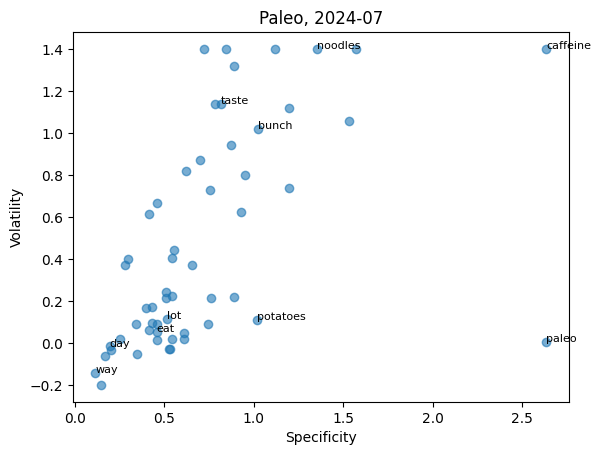

In [25]:
plot_specificity_by_volatility('Paleo','2024-07')

2. **Community: Mediterranean Diet, Period: July 2024**


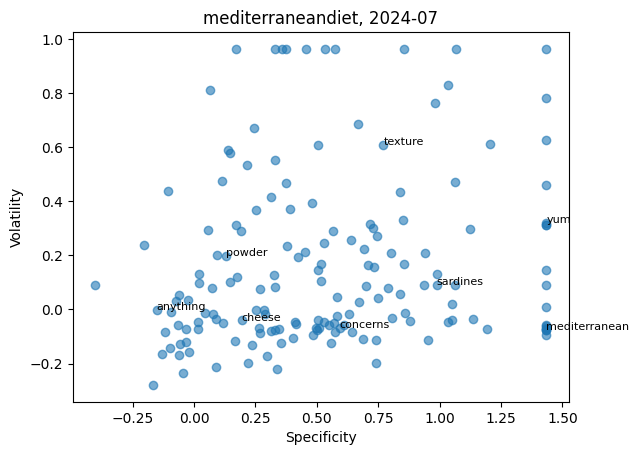

In [28]:
plot_specificity_by_volatility('mediterraneandiet','2024-07',max_labels=8)

3. **Community: Whole30, Period: July 2024**


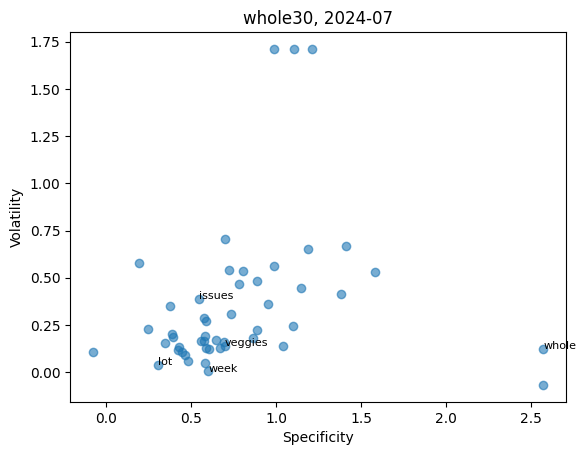

In [29]:
plot_specificity_by_volatility('whole30','2024-07',max_labels=5)

4. **Community: Vegan Keto, Period: May 2024**


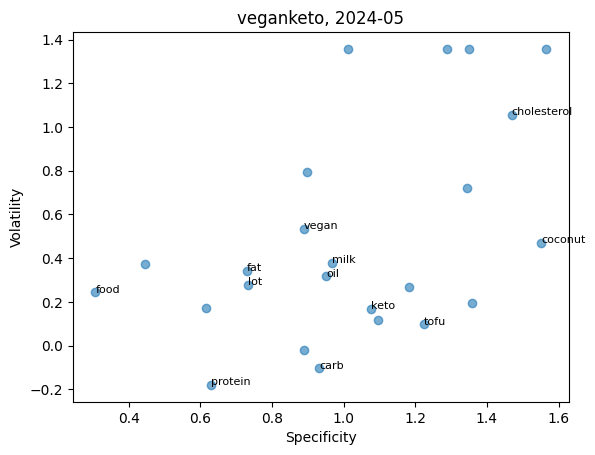

In [30]:
plot_specificity_by_volatility('veganketo','2024-05')


### Calculating and Visualizing Community Metrics

This section defines key metrics for analyzing community vocabulary and user behavior over time. These metrics include:

- **Distinctiveness:** Measures how unique a community's language is.
- **Dynamicity:** Measures the consistency of language usage over time.
- **User Retention:** Measures how well a community retains users between time periods.

---

#### Distinctiveness of a Community

The `distinctiveness` function calculates the average specificity of all words in a community across periods. A higher value indicates a more distinctive identity, while a lower value indicates a generic language style.


In [31]:
def distinctiveness(community):
    arr = [specificity(word, community, period)
            for period in communities_periods[community]
            for word in communities_periods[community][period]
           ]
    return np.array(arr).mean()

**Output:**

In [32]:
arr_distinctiveness = np.array([distinctiveness(community) for community in communities],dtype=np.float64)
for idx, community in enumerate(communities):
    print(f" {community} {arr_distinctiveness[idx]}")

 Paleo 0.7470086376323429
 carnivore 0.5086053321196659
 keto 0.20587295252519658
 mediterraneandiet 0.7200773041603399
 nutrition 0.2276267406006648
 vegan 0.12743485881090605
 veganketo 1.2554770150959729
 whole30 0.7722097975496713


#### Dynamicity of a Community

The `dynamicity` function calculates the average volatility of all words in a community across periods. A stable community exhibits lower dynamicity, while a more dynamic community has higher values.

In [33]:
def dynamicity(community):
    arr = [volatility(word, community, period)
            for period in communities_periods[community]
            for word in communities_periods[community][period]
           ]
    return np.array(arr).mean()

**Output:**


In [34]:
arr_dynamicity = np.array([dynamicity(community) for community in communities],dtype=np.float64)
for idx, community in enumerate(communities):
    print(f" {community} {arr_dynamicity[idx]}")

 Paleo 0.42139899891872645
 carnivore 0.23863365261196312
 keto 0.1048236724189001
 mediterraneandiet 0.24710698322605956
 nutrition 0.12707849324955517
 vegan 0.10945050302113438
 veganketo 0.6374949165257743
 whole30 0.4085175818846394


#### User Retention Between Periods

The `retention` function calculates the retention rate of users in a community between consecutive periods. Higher values indicate better retention.

In [35]:
def retention(community):
    arr = np.zeros(len(periods)-1)
    for i in range(len(periods)-1):
        users_t0 = {corpus.get_utterance(id).speaker.id for id in  corpus.get_utterance_ids(lambda utt: utt.meta["subreddit"]== community and utt.meta["period"]== periods[i])}
        if len(users_t0) == 0:
            continue
        users_ret_t1 = {corpus.get_utterance(id).speaker.id for id in  corpus.get_utterance_ids(lambda utt: utt.meta["subreddit"]== community and utt.meta["period"]== periods[i+1] and utt.speaker.id in users_t0)}
        arr[i] = len(users_ret_t1) / len(users_t0)
    return np.array(arr).mean()

**Output:**

In [36]:
arr_retention = np.zeros_like(arr_dynamicity)
for idx, community in enumerate(communities):
    arr_retention[idx] = retention(community)
    print(f" {community} {arr_retention[idx]}")

 Paleo 0.30304077270154217
 carnivore 0.5087051932696295
 keto 0.5414740163692975
 mediterraneandiet 0.4407307993655349
 nutrition 0.4975771243388986
 vegan 0.5364488917138639
 veganketo 0.27991839806053626
 whole30 0.34650395820701163


#### Visualizing Dynamicity, Distinctiveness, and Retention

To analyze all three metrics across communities, we use a scatter plot where:

- **X-Axis:** Distinctiveness
- **Y-Axis:** Dynamicity
- **Color:** User retention rate

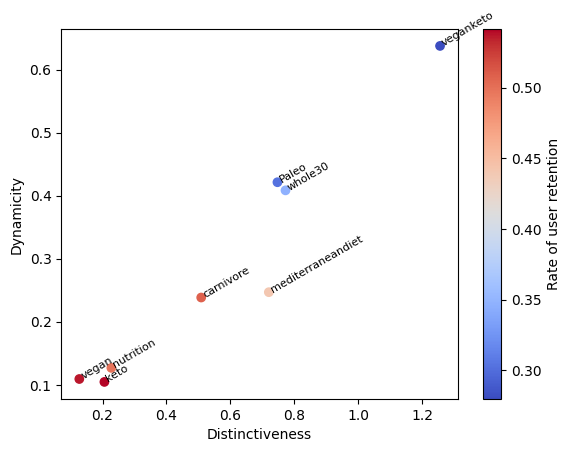

In [37]:
fig, ax = plt.subplots()
ax.scatter(arr_distinctiveness, arr_dynamicity, c=arr_retention, cmap='coolwarm')

for idx, community in enumerate(communities):
    ax.annotate(community, (arr_distinctiveness[idx], arr_dynamicity[idx]),size=8,rotation=30)
plt.xlabel("Distinctiveness")
plt.ylabel("Dynamicity")
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label("Rate of user retention")

plt.show()